In [1]:
!nvidia-smi

Sat Apr 25 22:26:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!rm -rf /content/DesignGym
!git clone https://huggingface.co/spaces/yashvyasop/DesignGym /content/DesignGym
%cd /content/DesignGym
!pip install -q -e .

Cloning into '/content/DesignGym'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 94 (delta 11), reused 0 (delta 0), pack-reused 45 (from 1)
Receiving objects: 100% (94/94), 438.84 KiB | 2.61 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/DesignGym
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.6/174.6 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.6/728.6 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━

In [3]:
!ls
!ls server
!ls training

assets	      models.py			  server
client.py     openenv_DesignGym.egg-info  training
data	      openenv.yaml		  uv.lock
Dockerfile    outputs			  validate-submission.sh
inference.py  pyproject.toml		  web
__init__.py   README.md
app.py	   DesignGym_environment.py  __init__.py  requirements.txt
briefs.py  Dockerfile		     phases.py	  rewards.py
generate_sft_data.py


In [4]:
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps trl peft accelerate bitsandbytes datasets transformers matplotlib pandas tqdm

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.3 MB/s eta 0:00:00


In [5]:
import json
import re
import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm
from peft import PeftModel
from unsloth import FastLanguageModel

from models import DesignGymAction
from server.DesignGym_environment import DesignGymEnvironment

try:
    from training.generate_sft_data import SYSTEM_PROMPT, prompt_from_obs
    print("Imported prompt builder from training/generate_sft_data.py")
except Exception as e:
    print("Could not import prompt builder, using fallback:", e)

    SYSTEM_PROMPT = (
        "You are a long-horizon spatial layout design agent. "
        "You receive a design brief, current phase, layout state, metrics, and feedback. "
        "Output exactly one valid minified JSON action object and nothing else."
    )

    def prompt_from_obs(obs):
        payload = {
            "task_id": getattr(obs, "task_id", ""),
            "step_count": getattr(obs, "step_count", 0),
            "max_steps": getattr(obs, "max_steps", 0),
            "phase": getattr(obs, "phase", ""),
            "allowed_actions": getattr(obs, "allowed_actions", []),
            "current_score": round(float(getattr(obs, "current_score", 0.0) or 0.0), 4),
            "best_score_so_far": round(float(getattr(obs, "best_score_so_far", 0.0) or 0.0), 4),
            "instruction_score": round(float(getattr(obs, "instruction_score", 0.0) or 0.0), 4),
            "brief": getattr(obs, "brief", {}) or {},
            "metrics": getattr(obs, "metrics", {}) or {},
            "metric_deltas": getattr(obs, "metric_deltas", {}) or {},
            "worst_metrics": getattr(obs, "worst_metrics", []) or [],
            "focus_elements": getattr(obs, "focus_elements", []) or [],
            "critic_feedback": getattr(obs, "critic_feedback", []) or [],
            "layout_summary": getattr(obs, "layout_summary", "") or "",
        }

        action_schema = {
            "action_type": "apply_template | anchor_to_region | resize | move | align | distribute | promote | reflow_group | finalize",
            "optional_fields": {
                "template_id": "hero | split | editorial | grid | draft",
                "element_id": "single element id",
                "element_ids": "list of element ids",
                "region_id": "semantic target region",
                "group_id": "semantic group id",
                "pattern": "stack | row",
                "axis": "x | y",
                "mode": "left | center | top",
                "dx_dy_dw_dh": "small normalized floats",
                "strength": "small float for promote",
            },
        }

        return (
            "Choose the next best layout edit.\n"
            "Output only one valid minified JSON action object.\n\n"
            f"STATE:\n{json.dumps(payload, sort_keys=True)}\n\n"
            f"ACTION_SCHEMA:\n{json.dumps(action_schema, sort_keys=True)}"
        )

/tmp/ipykernel_7237/822179186.py:11: UserWarning: WARNING: Unsloth should be imported before [transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Imported prompt builder from training/generate_sft_data.py


In [6]:
BASE_MODEL = "unsloth/Qwen2.5-0.5B-Instruct"
MAX_SEQ_LENGTH = 4096

ALLOWED_ACTION_TYPES = {
    "apply_template",
    "anchor_to_region",
    "resize",
    "move",
    "align",
    "distribute",
    "promote",
    "reflow_group",
    "finalize",
}

def cleanup_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def extract_json_object(text):
    text = (text or "").strip()

    try:
        return json.loads(text), text
    except Exception:
        pass

    match = re.search(r"\{.*?\}", text, flags=re.DOTALL)
    if not match:
        return None, text

    candidate = match.group(0)
    try:
        return json.loads(candidate), candidate
    except Exception:
        return None, text

def load_policy(policy_name, adapter_id=None):
    print(f"Loading policy: {policy_name}")
    print("Adapter:", adapter_id)

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,
        load_in_4bit=True,
    )

    if adapter_id:
        model = PeftModel.from_pretrained(model, adapter_id)

    FastLanguageModel.for_inference(model)
    return model, tokenizer

def build_messages(obs):
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt_from_obs(obs)},
    ]

def generate_action(model, tokenizer, obs):
    messages = build_messages(obs)

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=96,
            temperature=0.0,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Decode only newly generated tokens.
    gen_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    generated = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()

    parsed, extracted = extract_json_object(generated)

    valid_json = parsed is not None
    valid_action_type = bool(valid_json and parsed.get("action_type") in ALLOWED_ACTION_TYPES)

    if not valid_action_type:
        # Use noop so the environment records invalid behavior instead of crashing.
        return DesignGymAction(action_type="noop"), generated, valid_json, False

    try:
        action = DesignGymAction(**parsed)
        return action, generated, True, True
    except Exception:
        return DesignGymAction(action_type="noop"), generated, True, False

In [7]:
def run_rollout(model, tokenizer, task_id, seed):
    env = DesignGymEnvironment()
    obs = env.reset(task_id=task_id, seed=seed)

    records = []

    valid_json_count = 0
    valid_action_type_count = 0
    env_rejected_count = 0
    early_finalize_count = 0

    max_steps = int(obs.max_steps)

    for step_idx in range(max_steps):
        if env.state.done:
            break

        action, raw_generation, valid_json, valid_action_type = generate_action(model, tokenizer, obs)

        valid_json_count += int(valid_json)
        valid_action_type_count += int(valid_action_type)

        if action.action_type == "finalize" and step_idx < int(0.70 * max_steps):
            early_finalize_count += 1

        obs = env.step(action)

        env_rejected = bool(obs.last_action_error)
        env_rejected_count += int(env_rejected)

        records.append({
            "task_id": task_id,
            "seed": seed,
            "step": step_idx + 1,
            "phase": obs.phase,
            "action_type": action.action_type,
            "action_json": action.canonical(),
            "raw_generation": raw_generation,
            "valid_json": valid_json,
            "valid_action_type": valid_action_type,
            "env_rejected": env_rejected,
            "last_action_error": obs.last_action_error,
            "reward": float(env.state.last_reward),
            "current_score": float(env.state.current_score),
            "instruction_score": float(env.state.instruction_score),
            "phase_score": float(env.state.phase_score),
            "done": bool(env.state.done),
        })

        if env.state.done:
            break

    n = max(1, len(records))

    summary = {
        "task_id": task_id,
        "seed": seed,
        "steps": len(records),
        "final_score": float(env.state.current_score),
        "instruction_score": float(env.state.instruction_score),
        "total_reward": float(env.state.total_reward),
        "valid_json_rate": valid_json_count / n,
        "valid_action_type_rate": valid_action_type_count / n,
        "env_rejection_rate": env_rejected_count / n,
        "early_finalize_count": early_finalize_count,
        "invalid_actions": int(env.state.invalid_actions),
        "no_progress_steps": int(env.state.no_progress_steps),
    }

    return summary, records

def evaluate_policy(policy_name, adapter_id=None, seeds=range(3)):
    model, tokenizer = load_policy(policy_name, adapter_id)

    tasks = [
        "poster_basic_v1",
        "editorial_cover_v1",
        "dense_flyer_v1",
    ]

    summaries = []
    step_rows = []

    for task_id in tasks:
        for seed in tqdm(list(seeds), desc=f"{policy_name}:{task_id}"):
            summary, records = run_rollout(model, tokenizer, task_id, seed)

            summary["policy"] = policy_name

            for r in records:
                r["policy"] = policy_name

            summaries.append(summary)
            step_rows.extend(records)

    del model
    cleanup_gpu()

    return pd.DataFrame(summaries), pd.DataFrame(step_rows)

In [9]:
SFT_ADAPTER_HUB = "yashvyasop/designgym2-sft-qwen05-lora"

In [10]:
sft_summary, sft_steps = evaluate_policy(
    policy_name="sft_qwen05",
    adapter_id=SFT_ADAPTER_HUB,
    seeds=range(3),
)

sft_summary

Loading policy: sft_qwen05
Adapter: yashvyasop/designgym2-sft-qwen05-lora
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

sft_qwen05:editorial_cover_v1:   0%|          | 0/3 [00:00<?, ?it/s]

Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

sft_qwen05:dense_flyer_v1:   0%|          | 0/3 [00:00<?, ?it/s]

Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

,task_id,seed,steps,final_score,instruction_score,total_reward,valid_json_rate,valid_action_type_rate,env_rejection_rate,early_finalize_count,invalid_actions,no_progress_steps,policy
0,poster_basic_v1,0,7,0.758428,0.625853,1.0,1.0,1.0,0.0,0,0,0,sft_qwen05
1,poster_basic_v1,1,7,0.730382,0.676245,1.0,1.0,1.0,0.0,0,0,0,sft_qwen05
2,poster_basic_v1,2,7,0.752926,0.614031,1.0,1.0,1.0,0.0,0,0,0,sft_qwen05
3,editorial_cover_v1,0,9,0.795026,0.499134,1.0,1.0,1.0,0.0,0,0,0,sft_qwen05
4,editorial_cover_v1,1,9,0.764855,0.529869,1.0,1.0,1.0,0.0,0,0,1,sft_qwen05
5,editorial_cover_v1,2,9,0.784571,0.500002,1.0,1.0,1.0,0.0,0,0,1,sft_qwen05
6,dense_flyer_v1,0,10,0.600724,0.674508,1.0,1.0,1.0,0.0,0,0,1,sft_qwen05
7,dense_flyer_v1,1,10,0.634607,0.775450,1.0,1.0,1.0,0.0,0,0,0,sft_qwen05
8,dense_flyer_v1,2,10,0.621026,0.684553,1.0,1.0,1.0,0.0,0,0,0,sft_qwen05


In [12]:
from pathlib import Path

RESULT_DIR = Path("/content/base_vs_sft_eval")
PLOT_DIR = RESULT_DIR / "plots"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SFT_ADAPTER_HUB = "yashvyasop/designgym2-sft-qwen05-lora"

print("RESULT_DIR:", RESULT_DIR)
print("SFT_ADAPTER_HUB:", SFT_ADAPTER_HUB)

RESULT_DIR: /content/base_vs_sft_eval
SFT_ADAPTER_HUB: yashvyasop/designgym2-sft-qwen05-lora


In [13]:
sft_summary.to_csv(RESULT_DIR / "sft_rollout_summary.csv", index=False)
sft_steps.to_csv(RESULT_DIR / "sft_rollout_steps.csv", index=False)

sft_task_summary = sft_summary.groupby("task_id")[[
    "final_score",
    "instruction_score",
    "total_reward",
    "valid_json_rate",
    "valid_action_type_rate",
    "env_rejection_rate",
    "early_finalize_count",
    "invalid_actions",
]].mean()

sft_task_summary

,final_score,instruction_score,total_reward,valid_json_rate,valid_action_type_rate,env_rejection_rate,early_finalize_count,invalid_actions
task_id,,,,,,,,
dense_flyer_v1,0.618786,0.711504,1.0,1.0,1.0,0.0,0.0,0.0
editorial_cover_v1,0.781484,0.509668,1.0,1.0,1.0,0.0,0.0,0.0
poster_basic_v1,0.747246,0.638710,1.0,1.0,1.0,0.0,0.0,0.0


In [14]:
base_summary, base_steps = evaluate_policy(
    policy_name="base_qwen05",
    adapter_id=None,
    seeds=range(3),
)

base_summary

Loading policy: base_qwen05
Adapter: None
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


base_qwen05:poster_basic_v1:   0%|          | 0/3 [00:00<?, ?it/s]

Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=96

base_qwen05:editorial_cover_v1:   0%|          | 0/3 [00:00<?, ?it/s]

Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

base_qwen05:dense_flyer_v1:   0%|          | 0/3 [00:00<?, ?it/s]

Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=96) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generati

,task_id,seed,steps,final_score,instruction_score,total_reward,valid_json_rate,valid_action_type_rate,env_rejection_rate,early_finalize_count,invalid_actions,no_progress_steps,policy
0,poster_basic_v1,0,7,0.718284,0.509367,0.0,0.0,0.0,1.0,0,7,7,base_qwen05
1,poster_basic_v1,1,7,0.735508,0.522308,0.0,0.0,0.0,1.0,0,7,7,base_qwen05
2,poster_basic_v1,2,7,0.718410,0.497980,0.0,0.0,0.0,1.0,0,7,7,base_qwen05
3,editorial_cover_v1,0,9,0.789650,0.480288,0.0,0.0,0.0,1.0,0,9,9,base_qwen05
4,editorial_cover_v1,1,9,0.799076,0.475315,0.0,0.0,0.0,1.0,0,9,9,base_qwen05
5,editorial_cover_v1,2,9,0.773596,0.474298,0.0,0.0,0.0,1.0,0,9,9,base_qwen05
6,dense_flyer_v1,0,10,0.575329,0.615929,0.0,0.0,0.0,1.0,0,10,10,base_qwen05
7,dense_flyer_v1,1,10,0.617276,0.595467,0.0,0.0,0.0,1.0,0,10,10,base_qwen05
8,dense_flyer_v1,2,10,0.576316,0.625145,0.0,0.0,0.0,1.0,0,10,10,base_qwen05


In [15]:
base_summary.to_csv(RESULT_DIR / "base_rollout_summary.csv", index=False)
base_steps.to_csv(RESULT_DIR / "base_rollout_steps.csv", index=False)

In [16]:
combined = pd.concat([base_summary, sft_summary], ignore_index=True)
combined_steps = pd.concat([base_steps, sft_steps], ignore_index=True)

combined.to_csv(RESULT_DIR / "base_vs_sft_rollout_summary.csv", index=False)
combined_steps.to_csv(RESULT_DIR / "base_vs_sft_rollout_steps.csv", index=False)

metrics = [
    "final_score",
    "instruction_score",
    "total_reward",
    "valid_json_rate",
    "valid_action_type_rate",
    "env_rejection_rate",
    "early_finalize_count",
    "invalid_actions",
]

summary_table = combined.groupby("policy")[metrics].mean().reset_index()
summary_table.to_csv(RESULT_DIR / "base_vs_sft_summary_table.csv", index=False)
summary_table.to_json(RESULT_DIR / "base_vs_sft_summary_table.json", orient="records", indent=2)

summary_table

,policy,final_score,instruction_score,total_reward,valid_json_rate,valid_action_type_rate,env_rejection_rate,early_finalize_count,invalid_actions
0,base_qwen05,0.700383,0.53290,0.0,0.0,0.0,1.0,0.0,8.666667
1,sft_qwen05,0.715838,0.61996,1.0,1.0,1.0,0.0,0.0,0.000000


In [17]:
task_table = combined.groupby(["policy", "task_id"])[metrics].mean().reset_index()
task_table.to_csv(RESULT_DIR / "base_vs_sft_by_task.csv", index=False)
task_table

,policy,task_id,final_score,instruction_score,total_reward,valid_json_rate,valid_action_type_rate,env_rejection_rate,early_finalize_count,invalid_actions
0,base_qwen05,dense_flyer_v1,0.589640,0.612180,0.0,0.0,0.0,1.0,0.0,10.0
1,base_qwen05,editorial_cover_v1,0.787441,0.476634,0.0,0.0,0.0,1.0,0.0,9.0
2,base_qwen05,poster_basic_v1,0.724067,0.509885,0.0,0.0,0.0,1.0,0.0,7.0
3,sft_qwen05,dense_flyer_v1,0.618786,0.711504,1.0,1.0,1.0,0.0,0.0,0.0
4,sft_qwen05,editorial_cover_v1,0.781484,0.509668,1.0,1.0,1.0,0.0,0.0,0.0
5,sft_qwen05,poster_basic_v1,0.747246,0.638710,1.0,1.0,1.0,0.0,0.0,0.0


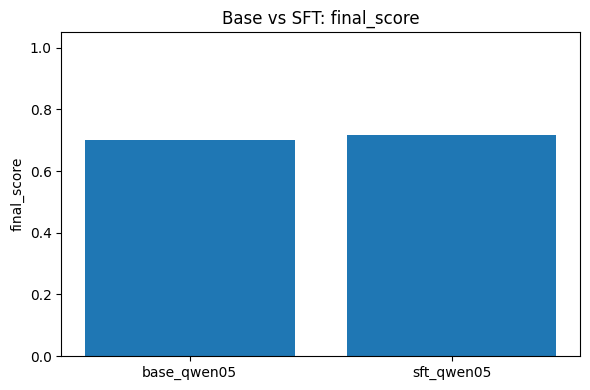

Saved: /content/base_vs_sft_eval/plots/base_vs_sft_final_score.png


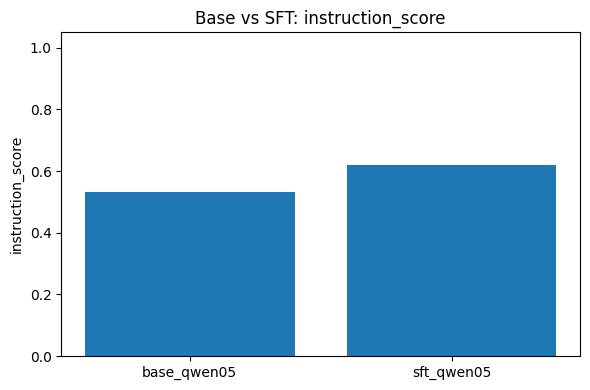

Saved: /content/base_vs_sft_eval/plots/base_vs_sft_instruction_score.png


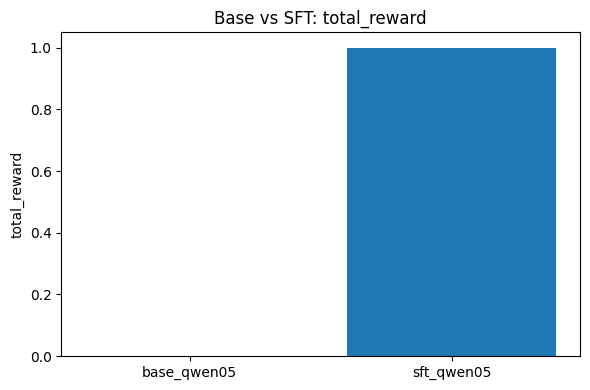

Saved: /content/base_vs_sft_eval/plots/base_vs_sft_total_reward.png


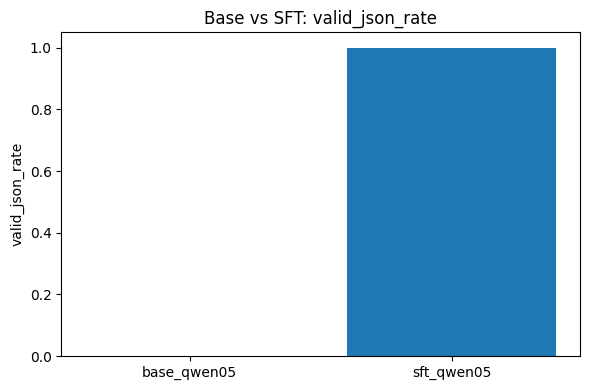

Saved: /content/base_vs_sft_eval/plots/base_vs_sft_valid_json_rate.png


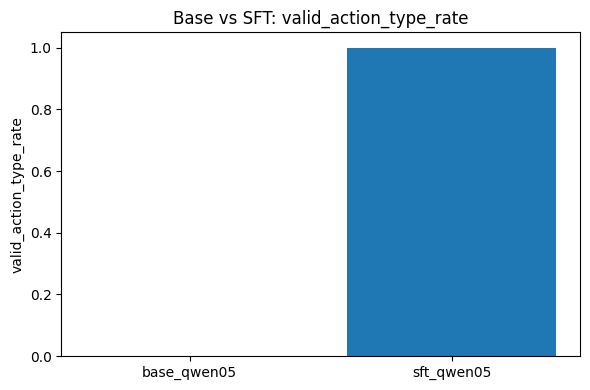

Saved: /content/base_vs_sft_eval/plots/base_vs_sft_valid_action_type_rate.png


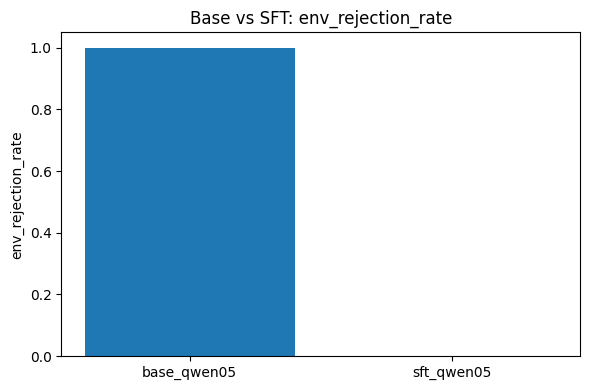

Saved: /content/base_vs_sft_eval/plots/base_vs_sft_env_rejection_rate.png


In [18]:
plot_metrics = [
    "final_score",
    "instruction_score",
    "total_reward",
    "valid_json_rate",
    "valid_action_type_rate",
    "env_rejection_rate",
]

for metric in plot_metrics:
    plt.figure(figsize=(6, 4))
    plt.bar(summary_table["policy"], summary_table[metric])
    plt.title(f"Base vs SFT: {metric}")
    plt.ylabel(metric)

    if metric not in {"early_finalize_count", "invalid_actions"}:
        plt.ylim(0, 1.05)

    plt.tight_layout()

    path = PLOT_DIR / f"base_vs_sft_{metric}.png"
    plt.savefig(path, dpi=160)
    plt.show()

    print("Saved:", path)

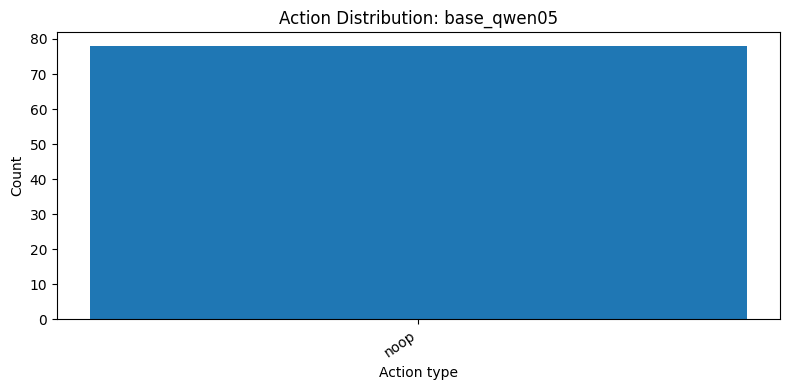

Saved: /content/base_vs_sft_eval/plots/action_distribution_base_qwen05.png


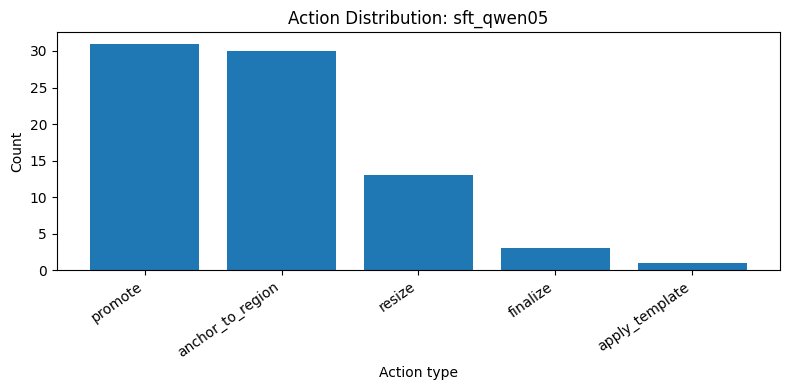

Saved: /content/base_vs_sft_eval/plots/action_distribution_sft_qwen05.png


In [19]:
action_counts = (
    combined_steps
    .groupby(["policy", "action_type"])
    .size()
    .reset_index(name="count")
)

action_counts.to_csv(RESULT_DIR / "base_vs_sft_action_counts.csv", index=False)

for policy in action_counts["policy"].unique():
    subset = action_counts[action_counts["policy"] == policy].sort_values("count", ascending=False)

    plt.figure(figsize=(8, 4))
    plt.bar(subset["action_type"], subset["count"])
    plt.title(f"Action Distribution: {policy}")
    plt.xlabel("Action type")
    plt.ylabel("Count")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()

    path = PLOT_DIR / f"action_distribution_{policy}.png"
    plt.savefig(path, dpi=160)
    plt.show()

    print("Saved:", path)

In [20]:
example_path = RESULT_DIR / "sft_rollout_examples.jsonl"

with open(example_path, "w", encoding="utf-8") as f:
    for _, row in sft_steps.head(30).iterrows():
        f.write(json.dumps(row.to_dict(), ensure_ascii=False) + "\n")

print("Saved:", example_path)

for _, row in sft_steps.head(10).iterrows():
    print("=" * 80)
    print("task:", row["task_id"], "seed:", row["seed"], "step:", row["step"])
    print("phase:", row["phase"])
    print("action:", row["action_json"])
    print("reward:", row["reward"], "score:", row["current_score"], "instruction:", row["instruction_score"])
    print("raw:", row["raw_generation"][:300])

Saved: /content/base_vs_sft_eval/sft_rollout_examples.jsonl
task: poster_basic_v1 seed: 0 step: 1
phase: structure
action: {"action_type":"anchor_to_region","anchor":"center","dh":0.0,"dw":0.0,"dx":0.0,"dy":0.0,"element_id":"cta","element_ids":[],"grid":0,"mode":"center","region_id":"safe_lower_right","strength":0.0}
reward: 0.160783 score: 0.7022348992208869 instruction: 0.6257801722384181
raw: {"action_type":"anchor_to_region","element_id":"cta","mode":"center","region_id":"safe_lower_right"}
task: poster_basic_v1 seed: 0 step: 2
phase: placement
action: {"action_type":"anchor_to_region","anchor":"center","dh":0.0,"dw":0.0,"dx":0.0,"dy":0.0,"element_id":"cta","element_ids":[],"grid":0,"mode":"center","region_id":"safe_lower_right","strength":0.0}
reward: 0.253583 score: 0.7165662236947825 instruction: 0.6257801722384181
raw: {"action_type":"anchor_to_region","element_id":"cta","mode":"center","region_id":"safe_lower_right"}
task: poster_basic_v1 seed: 0 step: 3
phase: refinement
acti

In [21]:
import shutil

zip_path = shutil.make_archive(
    str(RESULT_DIR),
    "zip",
    root_dir=str(RESULT_DIR),
)

print("Zipped:", zip_path)

Zipped: /content/base_vs_sft_eval.zip


In [22]:
from google.colab import files
files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>